## Importar datos

In [ ]:
import pandas as pd
import re
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Sport car price.csv")

In [ ]:
df

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
1002,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
1003,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
1004,McLaren,Senna,2021,4,789,590,2.7,"1,000,000"
1005,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


## Revisión detalles básicos del dataset

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1007 entries, 0 to 1006
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Car Make                 1007 non-null   object
 1   Car Model                1007 non-null   object
 2   Year                     1007 non-null   int64 
 3   Engine Size (L)          997 non-null    object
 4   Horsepower               1007 non-null   object
 5   Torque (lb-ft)           1004 non-null   object
 6   0-60 MPH Time (seconds)  1007 non-null   object
 7   Price (in USD)           1007 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.1+ KB


## Tratamiento de nulls

In [ ]:
print("Cantidad de filas con algún null:", df.isna().any(axis=1).sum())

Cantidad de filas con algún null: 12


In [ ]:
df[df.isna().any(axis=1)]

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
168,Rimac,C_Two,2022,NaN,1914,1696,1.9,"2,400,000"
171,Tesla,Model S Plaid,2021,NaN,1020,1050,1.98,"131,190"
222,Porsche,Taycan Turbo S,2021,NaN,750,774,2.6,"185,000"
247,Tesla,Model S Plaid,2022,NaN,1020,1050,1.9,"131,190"
387,Rimac,C_Two,2022,NaN,1888,1696,1.8,"2,400,000"
389,Tesla,Roadster,2022,NaN,10000+,0,1.9,"200,000"
642,Tesla,Model S Plaid,2021,Electric,1020,NaN,1.9,"139,990"
686,Rimac,C_Two,2022,NaN,1914,1696,1.85,"2,400,000"
697,Lotus,Evija,2022,NaN,1972,1254,2.5,"2,700,000"
752,Porsche,Taycan,2022,NaN,469,479,3.8,"79,900"


In [ ]:
# 1. Rellenar la fila con algún valor imputado.
df["Engine Size (L)"] = df["Engine Size (L)"].fillna("0")
df

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
1002,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
1003,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
1004,McLaren,Senna,2021,4,789,590,2.7,"1,000,000"
1005,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


In [ ]:
# 2. Eliminar las filas con nulas
#df = df[~df.isna().any(axis=1)]
df = df.dropna(axis=0)
df

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
1002,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
1003,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
1004,McLaren,Senna,2021,4,789,590,2.7,"1,000,000"
1005,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


In [ ]:
print("Cantidad de filas con algún null:", df.isna().any(axis=1).sum())

Cantidad de filas con algún null: 0


## Revisión de duplicados

In [ ]:
print("Cantidad de filas duplicadas:", df.duplicated().sum())

Cantidad de filas duplicadas: 288


In [ ]:
# Revisar cuáles son las que están duplicadas
df[df.duplicated(subset=["Car Make", "Car Model"])]

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
31,McLaren,Artura,2021,3,671,531,3,"225,000"
45,Lamborghini,Aventador SVJ,2021,6.5,759,531,2.8,"518,000"
46,Ferrari,SF90 Stradale,2021,4,986,590,2.5,"625,000"
47,Audi,RS3,2022,2.5,394,369,3.9,"56,200"
49,BMW,M4,2022,3,503,479,3.8,"71,800"
...,...,...,...,...,...,...,...,...
1002,Koenigsegg,Jesko,2022,5,1280,1106,2.5,"3,000,000"
1003,Lotus,Evija,2021,Electric Motor,1972,1254,2,"2,000,000"
1004,McLaren,Senna,2021,4,789,590,2.7,"1,000,000"
1005,Pagani,Huayra,2021,6,764,738,3,"2,600,000"


In [ ]:
df = df.drop_duplicates(subset=["Car Make", "Car Model"])
df

,Car Make,Car Model,Year,Engine Size (L),Horsepower,Torque (lb-ft),0-60 MPH Time (seconds),Price (in USD)
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
946,Porsche,Panamera GTS,2021,4,473,457,3.9,"134,150"
952,Mercedes-Benz,AMG GT 4-Door Coupe,2021,4,630,664,3.1,"171,200"
961,Mercedes-AMG,C63 S,2022,4,503,516,3.7,"78,100"
989,Maserati,MC20,2021,3,621,538,2.9,"210,000"


In [ ]:
print("Cantidad de filas duplicadas:", df.duplicated(subset=["Car Make", "Car Model"]).sum())

Cantidad de filas duplicadas: 0


## Renombrar columnas a un estándar

In [ ]:
df = df.reset_index(drop=True)

In [ ]:
df = df.rename(columns={
    "Engine Size (L)": "Engine Size",
    "Torque (lb-ft)": "Torque",
    "Price (in USD)": "Price",
    "0-60 MPH Time (seconds)": "Speed"
})
df

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price
0,Porsche,911,2022,3,379,331,4,"101,200"
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390"
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750"
3,Audi,R8,2022,5.2,562,406,3.2,"142,700"
4,McLaren,720S,2021,4,710,568,2.7,"298,000"
...,...,...,...,...,...,...,...,...
173,Porsche,Panamera GTS,2021,4,473,457,3.9,"134,150"
174,Mercedes-Benz,AMG GT 4-Door Coupe,2021,4,630,664,3.1,"171,200"
175,Mercedes-AMG,C63 S,2022,4,503,516,3.7,"78,100"
176,Maserati,MC20,2021,3,621,538,2.9,"210,000"


## Feature Engineering

In [ ]:
# Intentar cambiar tipo de dato a columnas que deberían ser numéricas
for col in ["Engine Size", "Horsepower", "Torque", "Speed", "Price"]:
  try:
    df[col].astype(float)
    print("SUCCESS: Sí se puede transformar la columna", col)
  except Exception as e:
    print("ERROR: Columna", col, "no es numérica", e)

ERROR: Columna Engine Size no es numérica could not convert string to float: 'Electric'
ERROR: Columna Horsepower no es numérica could not convert string to float: '1000+'
SUCCESS: Sí se puede transformar la columna Torque
SUCCESS: Sí se puede transformar la columna Speed
ERROR: Columna Price no es numérica could not convert string to float: '101,200'


In [ ]:
def assign_engine_type(x):
  if(x["Engine Size"] == "0" or
     "Electric" in x["Engine Size"]
     or x["Car Make"] == "Tesla"
    ):
    return "Electric Motor"
  else:
    return "Gas Motor"

In [ ]:
df["Engine Type"] = df.apply(assign_engine_type, axis=1)
df

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price,Engine Type
0,Porsche,911,2022,3,379,331,4,"101,200",Gas Motor
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390",Gas Motor
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750",Gas Motor
3,Audi,R8,2022,5.2,562,406,3.2,"142,700",Gas Motor
4,McLaren,720S,2021,4,710,568,2.7,"298,000",Gas Motor
...,...,...,...,...,...,...,...,...,...
173,Porsche,Panamera GTS,2021,4,473,457,3.9,"134,150",Gas Motor
174,Mercedes-Benz,AMG GT 4-Door Coupe,2021,4,630,664,3.1,"171,200",Gas Motor
175,Mercedes-AMG,C63 S,2022,4,503,516,3.7,"78,100",Gas Motor
176,Maserati,MC20,2021,3,621,538,2.9,"210,000",Gas Motor


In [ ]:
df["Engine Size"] = df.apply(lambda x: "0" if (x["Engine Type"] == "Electric Motor") else x["Engine Size"], axis=1)
# Eliminar Hybrids
df["Engine Size"] = df["Engine Size"].apply(lambda x: re.sub("[^0-9.]", "", x))
# Rellenar cadenas vacías "" con 0
df["Engine Size"] = df["Engine Size"].apply(lambda x: "0" if x == "" else x)
# Castear a float
df["Engine Size"] = df["Engine Size"].astype(float)
df

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price,Engine Type
0,Porsche,911,2022,3.0,379,331,4,"101,200",Gas Motor
1,Lamborghini,Huracan,2021,5.2,630,443,2.8,"274,390",Gas Motor
2,Ferrari,488 GTB,2022,3.9,661,561,3,"333,750",Gas Motor
3,Audi,R8,2022,5.2,562,406,3.2,"142,700",Gas Motor
4,McLaren,720S,2021,4.0,710,568,2.7,"298,000",Gas Motor
...,...,...,...,...,...,...,...,...,...
173,Porsche,Panamera GTS,2021,4.0,473,457,3.9,"134,150",Gas Motor
174,Mercedes-Benz,AMG GT 4-Door Coupe,2021,4.0,630,664,3.1,"171,200",Gas Motor
175,Mercedes-AMG,C63 S,2022,4.0,503,516,3.7,"78,100",Gas Motor
176,Maserati,MC20,2021,3.0,621,538,2.9,"210,000",Gas Motor


In [ ]:
df[df.duplicated()]

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price,Engine Type


In [ ]:
df["Horsepower"] = df["Horsepower"].apply(lambda x: re.sub("[^0-9.]", "", x)).astype(float)

In [ ]:
df["Torque"] = df["Torque"].apply(lambda x: re.sub("[^0-9.]", "", x))
df["Torque"] = df["Torque"].apply(lambda x: "0" if x == "" else x)
df["Torque"] = df["Torque"].astype(float)

In [ ]:
df["Speed"] = df["Speed"].apply(lambda x: re.sub("[^0-9.]", "", x)).astype(float)

In [ ]:
df["Price"] = df["Price"].apply(lambda x: x.replace(",", "")).astype(float)

In [ ]:
df["Antiquity"] = datetime.date.today().year - df["Year"]

In [ ]:
df

,Car Make,Car Model,Year,Engine Size,Horsepower,Torque,Speed,Price,Engine Type,Antiquity
0,Porsche,911,2022,3.0,379.0,331.0,4.0,101200.0,Gas Motor,3
1,Lamborghini,Huracan,2021,5.2,630.0,443.0,2.8,274390.0,Gas Motor,4
2,Ferrari,488 GTB,2022,3.9,661.0,561.0,3.0,333750.0,Gas Motor,3
3,Audi,R8,2022,5.2,562.0,406.0,3.2,142700.0,Gas Motor,3
4,McLaren,720S,2021,4.0,710.0,568.0,2.7,298000.0,Gas Motor,4
...,...,...,...,...,...,...,...,...,...,...
173,Porsche,Panamera GTS,2021,4.0,473.0,457.0,3.9,134150.0,Gas Motor,4
174,Mercedes-Benz,AMG GT 4-Door Coupe,2021,4.0,630.0,664.0,3.1,171200.0,Gas Motor,4
175,Mercedes-AMG,C63 S,2022,4.0,503.0,516.0,3.7,78100.0,Gas Motor,3
176,Maserati,MC20,2021,3.0,621.0,538.0,2.9,210000.0,Gas Motor,4


## EDA (Análisis Exploratorio de la Data)

### Estadísticas y gráfica básicas

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Car Make     178 non-null    object 
 1   Car Model    178 non-null    object 
 2   Year         178 non-null    int64  
 3   Engine Size  178 non-null    float64
 4   Horsepower   178 non-null    float64
 5   Torque       178 non-null    float64
 6   Speed        178 non-null    float64
 7   Price        178 non-null    float64
 8   Engine Type  178 non-null    object 
 9   Antiquity    178 non-null    int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 14.0+ KB


In [ ]:
df.describe()

,Year,Engine Size,Horsepower,Torque,Speed,Price,Antiquity
count,178.000000,178.000000,178.000000,178.000000,178.000000,1.780000e+02,178.000000
mean,2020.837079,4.033146,617.601124,555.477528,3.526461,4.232327e+05,4.162921
std,4.385567,1.760609,303.422220,247.569318,0.811286,8.616980e+05,4.385567
min,1965.000000,0.000000,181.000000,151.000000,1.850000,2.500000e+04,2.000000
25%,2021.000000,3.000000,444.000000,406.000000,2.900000,7.010000e+04,3.000000
50%,2021.000000,4.000000,591.000000,516.000000,3.500000,1.145225e+05,4.000000
75%,2022.000000,5.150000,705.000000,625.750000,3.900000,2.250000e+05,4.000000
max,2023.000000,8.400000,1973.000000,1696.000000,6.500000,5.200000e+06,60.000000


<Axes: xlabel='Car Make'>

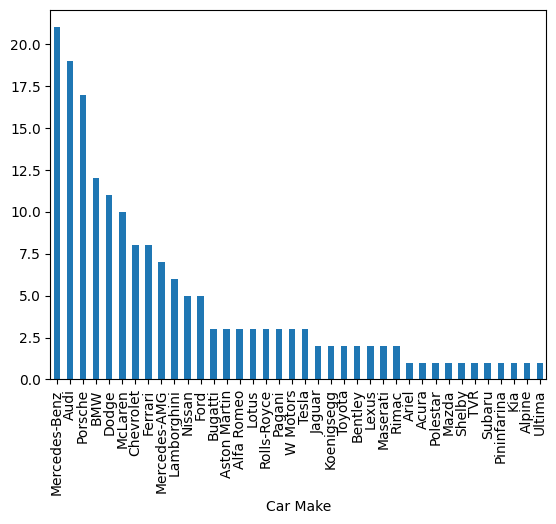

In [ ]:
df["Car Make"].value_counts().plot(kind="bar")

In [ ]:
# Homologar nombres de fabricantes
def homologar_fabricantes(x):
  if "mercedes" in x.lower():
    return "Mercedes"
  if "audi" in x.lower():
    "Audi"
  return x


<Axes: xlabel='Car Make'>

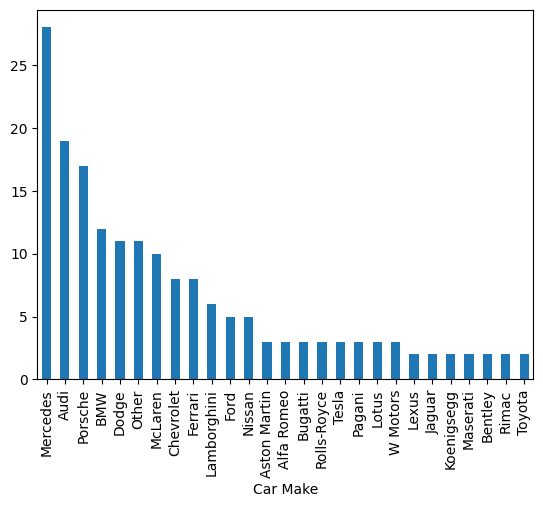

In [ ]:
# Homologar categorías
df["Car Make"] = df["Car Make"].apply(homologar_fabricantes)
# Agrupar en otros
maker_counts = df["Car Make"].value_counts()
df["Car Make"] = df["Car Make"].apply(lambda x: "Other" if maker_counts[x] < 2 else x)
# Imprimir resultado
df["Car Make"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

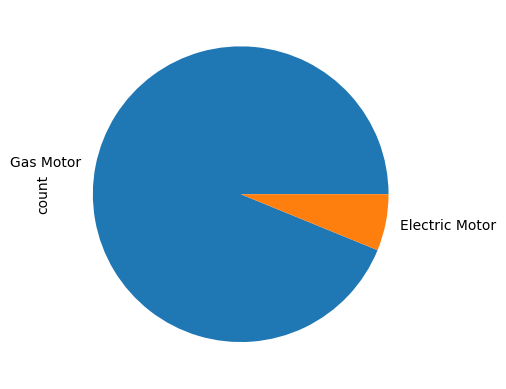

In [ ]:
df["Engine Type"].value_counts().plot(kind="pie")

<Axes: >

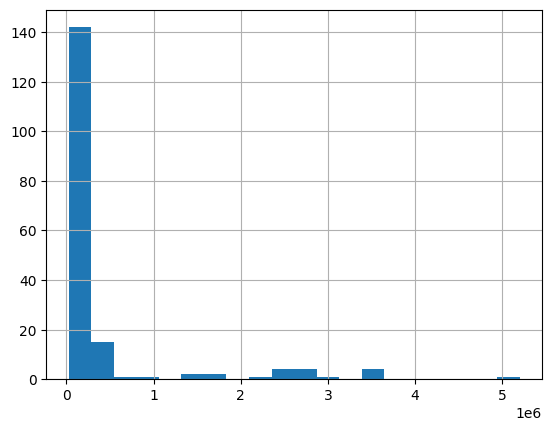

In [ ]:
df["Price"].hist(bins=20)

<Axes: >

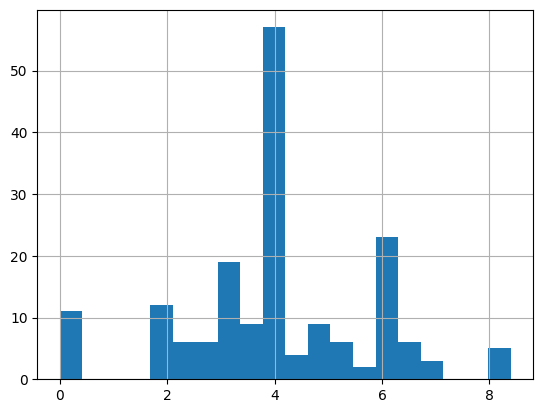

In [ ]:
df["Engine Size"].hist(bins=20)

<Axes: >

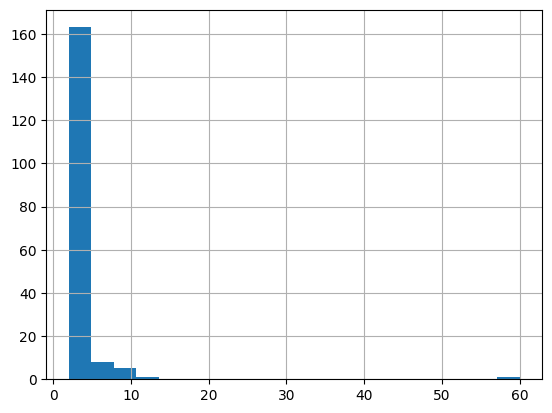

In [ ]:
df["Antiquity"].hist(bins=20)

### Interacciones entre variables

<Axes: xlabel='Car Make', ylabel='Price'>

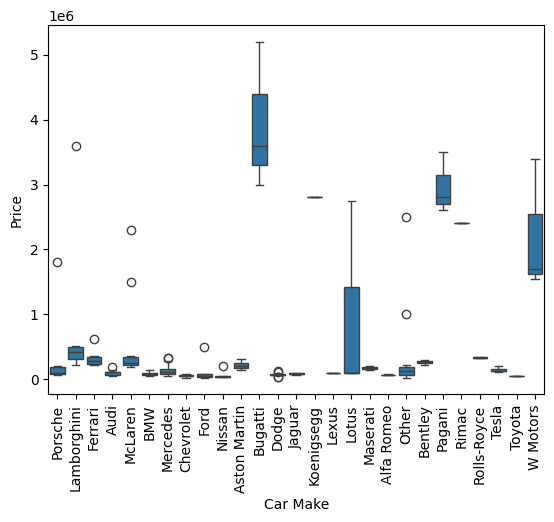

In [ ]:
# Categóricas-numéricas boxplots

plt.xticks(rotation=90)
sns.boxplot(x="Car Make", y="Price", data=df)

<Axes: xlabel='Engine Type', ylabel='Price'>

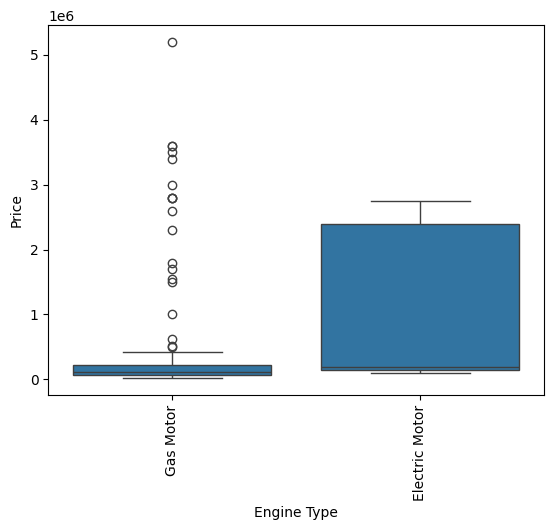

In [ ]:
plt.xticks(rotation=90)
sns.boxplot(x="Engine Type", y="Price", data=df)

<Axes: xlabel='Antiquity', ylabel='Price'>

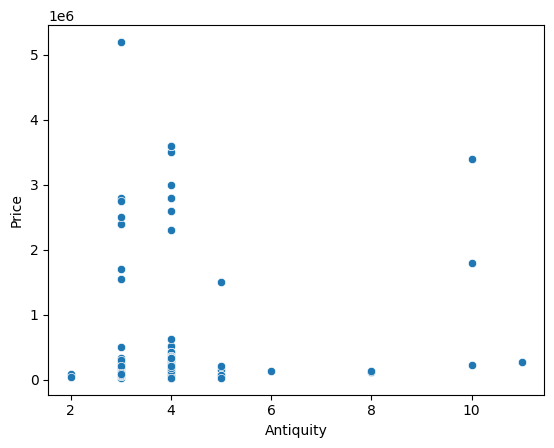

In [ ]:
# Númericas-numéricas scatterplots
df_without_antiquity_outlier = df[df["Antiquity"] < 20]
sns.scatterplot(x="Antiquity", y="Price", data=df_without_antiquity_outlier)

<Axes: xlabel='Speed', ylabel='Price'>

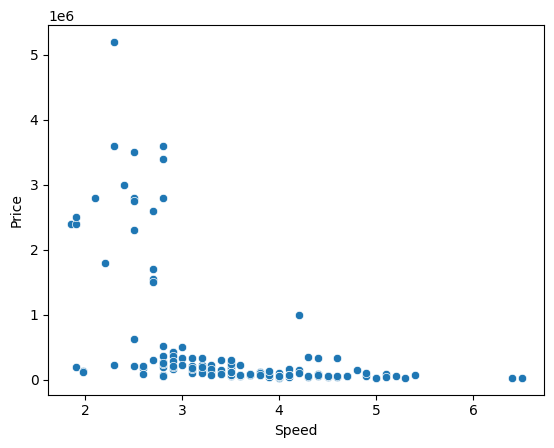

In [ ]:
# Númericas-numéricas scatterplots
sns.scatterplot(x="Speed", y="Price", data=df)

<Axes: xlabel='Horsepower', ylabel='Price'>

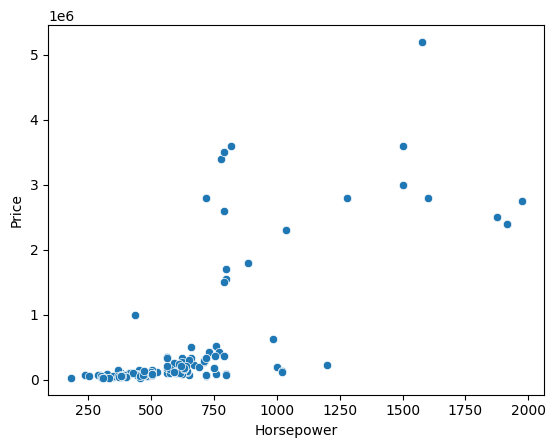

In [ ]:
# Númericas-numéricas scatterplots
sns.scatterplot(x="Horsepower", y="Price", data=df)

In [ ]:
# Correlaciones

df.select_dtypes(include="number").corr()

,Year,Engine Size,Horsepower,Torque,Speed,Price,Antiquity
Year,1.000000,-0.181931,0.047367,0.036045,-0.039067,-0.080108,-1.000000
Engine Size,-0.181931,1.000000,0.055031,0.020831,-0.077985,0.169326,0.181931
Horsepower,0.047367,0.055031,1.000000,0.945927,-0.728448,0.719354,-0.047367
Torque,0.036045,0.020831,0.945927,1.000000,-0.700646,0.643492,-0.036045
Speed,-0.039067,-0.077985,-0.728448,-0.700646,1.000000,-0.486541,0.039067
Price,-0.080108,0.169326,0.719354,0.643492,-0.486541,1.000000,0.080108
Antiquity,-1.000000,0.181931,-0.047367,-0.036045,0.039067,0.080108,1.000000
